In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime
from datetime import date

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

%matplotlib inline


In [192]:
df = pd.read_csv("Data/train_info.csv")
df_second = pd.read_csv("Data/clients_a_contacter.csv")

# Partie 1 : EDA Exploration des données  

In [19]:
df.head()

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0


In [20]:
df.columns

Index(['id_client', 'genre', 'age', 'permis_conduire', 'code_regional', 'ancien_assure', 'age_vehicule', 'vehicule_endommage',
       'prime_annuelle', 'canal_communication', 'anciennete', 'reponse_client'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_client            381109 non-null  int64  
 1   genre                381109 non-null  object 
 2   age                  381109 non-null  int64  
 3   permis_conduire      381109 non-null  int64  
 4   code_regional        381109 non-null  float64
 5   ancien_assure        381109 non-null  int64  
 6   age_vehicule         381109 non-null  object 
 7   vehicule_endommage   381109 non-null  object 
 8   prime_annuelle       381109 non-null  float64
 9   canal_communication  381109 non-null  float64
 10  anciennete           381109 non-null  int64  
 11  reponse_client       381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [22]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", numerical_columns)

Numerical columns: ['id_client', 'age', 'permis_conduire', 'code_regional', 'ancien_assure', 'prime_annuelle', 'canal_communication', 'anciennete', 'reponse_client']


In [23]:
df.describe()

,id_client,age,permis_conduire,code_regional,ancien_assure,prime_annuelle,canal_communication,anciennete,reponse_client
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


#### la plus part des client entre 20 - 50
#### la majourite de 0.997 sont des permis les autres propablement des erreur 812/381109
#### 46% des client sont deja assures 
#### mouene des prime_annuelle envirant de 30564 entre 2630 et 39400 
#### personne n a encore depase le 300j d anciennte 
#### moins que 13% qui veux faire l insscription 

In [26]:
df.duplicated().sum()

0

In [27]:
df.isna().sum()

id_client              0
genre                  0
age                    0
permis_conduire        0
code_regional          0
ancien_assure          0
age_vehicule           0
vehicule_endommage     0
prime_annuelle         0
canal_communication    0
anciennete             0
reponse_client         0
dtype: int64

#### Le dataset ne contient ni valeurs manquantes ni doublons, ce qui indique une bonne qualité des données.

In [28]:
df.shape

(381109, 12)

In [29]:
numerical_columns.remove("id_client")

In [30]:
len(numerical_columns)

8

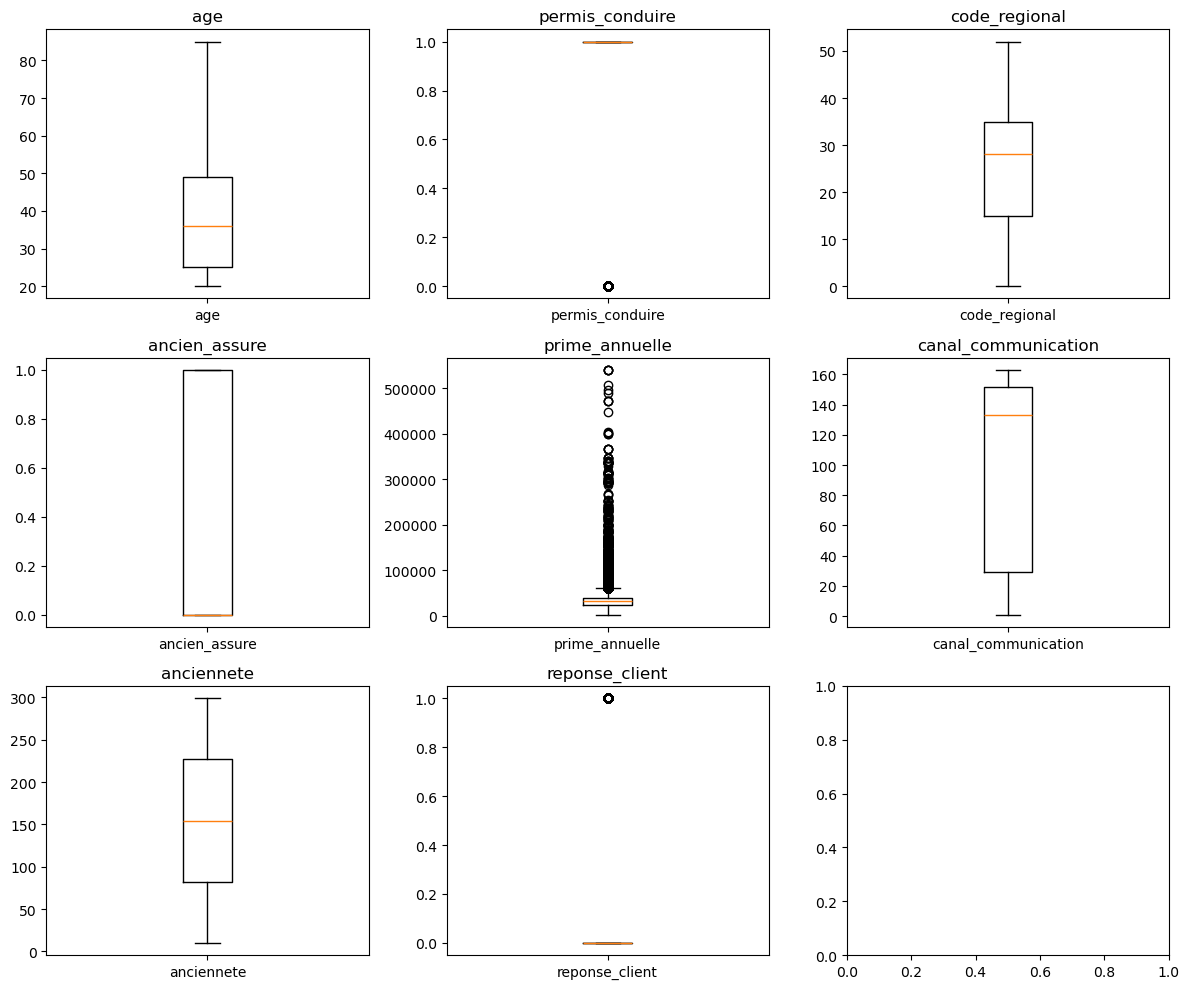

In [31]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))  # largeur, hauteur en pouces
axes = axes.flatten()

for i, col in enumerate(numerical_columns[:9]):
    axes[i].boxplot(df[col], labels=[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#### donc le prime annuelle ce lui qui contient plus de decalage et des valeurs aberrantes </br> possible parceque on plus de type d assurence et peux changer depend de type de voiture 

In [32]:
# pour prime annuelle
Q1 = df["prime_annuelle"].quantile(0.25)
Q3 = df["prime_annuelle"].quantile(0.75)
IQR = Q3 - Q1
born_inf = Q1 - 1.5 * IQR
born_sup = Q3 + 1.5 * IQR
print(f"Bornes pour prime_annuelle : [{born_inf}, {born_sup}]")

Bornes pour prime_annuelle : [1912.5, 61892.5]


In [33]:
df.loc[(df["prime_annuelle"] < born_inf) | (df["prime_annuelle"] > born_sup)].shape

(10320, 12)

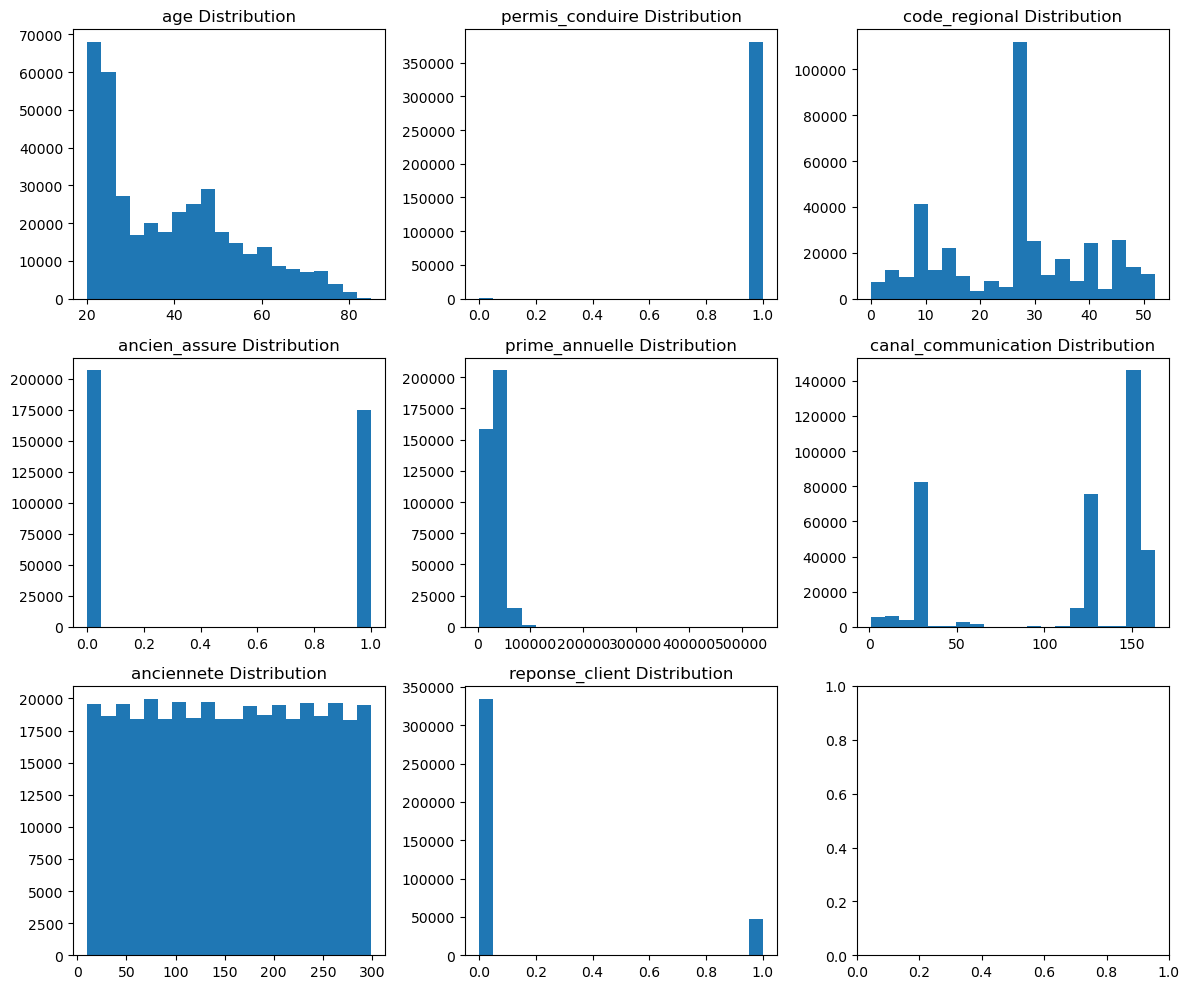

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))  
axes = axes.flatten()

for i, col in enumerate(numerical_columns[:9]):
    axes[i].hist(df[col] , bins=20)
    axes[i].set_title(col + " Distribution")

plt.tight_layout()
plt.show()

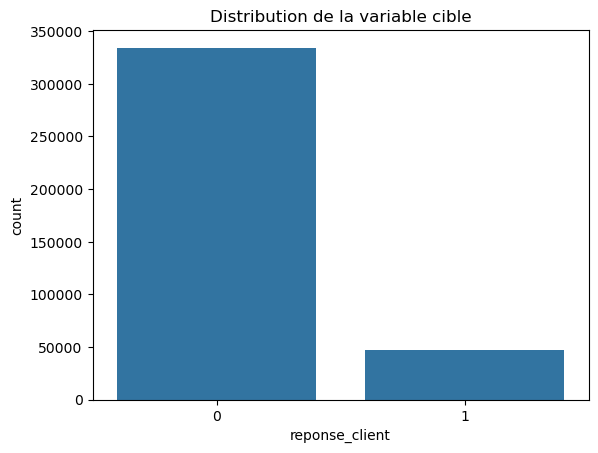

reponse_client
0    0.877437
1    0.122563
Name: proportion, dtype: float64

In [36]:
sns.countplot(x=df["reponse_client"])
plt.title("Distribution de la variable cible")
plt.show()

df["reponse_client"].value_counts(normalize=True)

In [37]:
# Variables catégorielles
categorical_columns = df.select_dtypes(include='object').columns
print("Categorical columns:", categorical_columns)

Categorical columns: Index(['genre', 'age_vehicule', 'vehicule_endommage'], dtype='object')


In [38]:
for col in categorical_columns:
    print(df[col].value_counts())

genre
male       206089
femelle    175020
Name: count, dtype: int64
age_vehicule
1-2 an     200316
< 1 an     164786
> 2 ans     16007
Name: count, dtype: int64
vehicule_endommage
oui    192413
no     188696
Name: count, dtype: int64


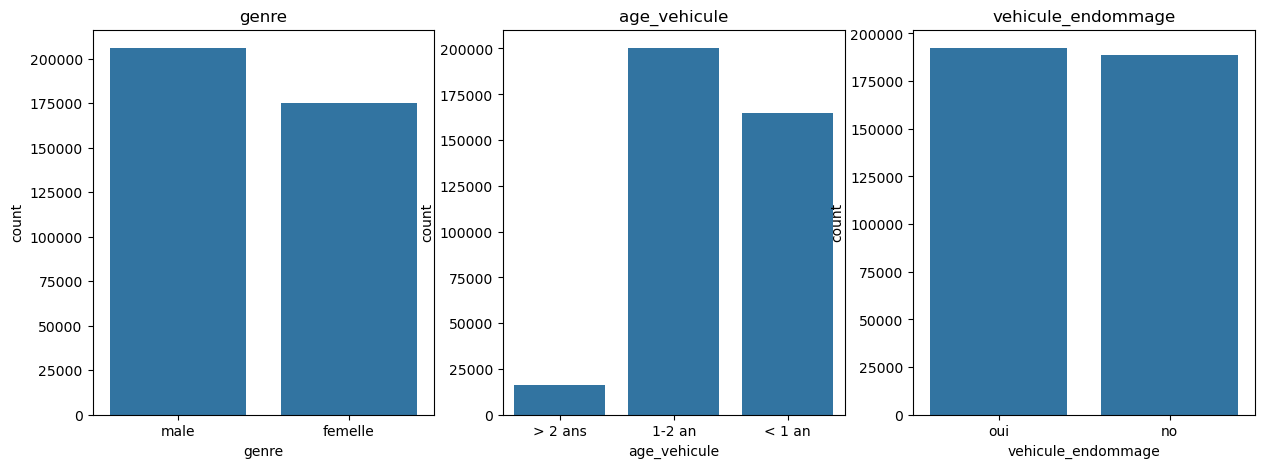

In [39]:
fg , axes = plt.subplots(1, 3 , figsize=(15, 5))  
for i , col in enumerate(categorical_columns):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

In [40]:
df.describe(include="object")

,genre,age_vehicule,vehicule_endommage
count,381109,381109,381109
unique,2,3,2
top,male,1-2 an,oui
freq,206089,200316,192413


In [41]:
categorical_columns

Index(['genre', 'age_vehicule', 'vehicule_endommage'], dtype='object')

In [42]:
df[['genre', 'age_vehicule', 'vehicule_endommage','reponse_client']]

,genre,age_vehicule,vehicule_endommage,reponse_client
0,male,> 2 ans,oui,1
1,male,1-2 an,no,0
2,male,> 2 ans,oui,1
3,male,< 1 an,no,0
4,femelle,< 1 an,no,0
...,...,...,...,...
381104,male,1-2 an,no,0
381105,male,< 1 an,no,0
381106,male,< 1 an,no,0
381107,femelle,> 2 ans,oui,0


In [44]:
df.groupby(['genre', 'age_vehicule', 'vehicule_endommage'])['reponse_client'].value_counts(normalize=True).unstack().fillna(0)

reponse_client                                  0         1
genre   age_vehicule vehicule_endommage                    
femelle 1-2 an       no                  0.992389  0.007611
                     oui                 0.729730  0.270270
        < 1 an       no                  0.997048  0.002952
                     oui                 0.877977  0.122023
        > 2 ans      no                  1.000000  0.000000
                     oui                 0.732760  0.267240
male    1-2 an       no                  0.991283  0.008717
                     oui                 0.735330  0.264670
        < 1 an       no                  0.996221  0.003779
                     oui                 0.837187  0.162813
        > 2 ans      no                  1.000000  0.000000
                     oui                 0.691149  0.308851

In [45]:
# on peux ingorer pour le moment le genre 
df.groupby([ 'age_vehicule', 'vehicule_endommage'])['reponse_client'].value_counts(normalize=True).unstack().fillna(0)

reponse_client                          0         1
age_vehicule vehicule_endommage                    
1-2 an       no                  0.991733  0.008267
             oui                 0.733203  0.266797
< 1 an       no                  0.996689  0.003311
             oui                 0.858577  0.141423
> 2 ans      no                  1.000000  0.000000
             oui                 0.705978  0.294022

#### Plus le véhicule est ancien et endommagé, plus la probabilité que le client réponde positivement augmente.

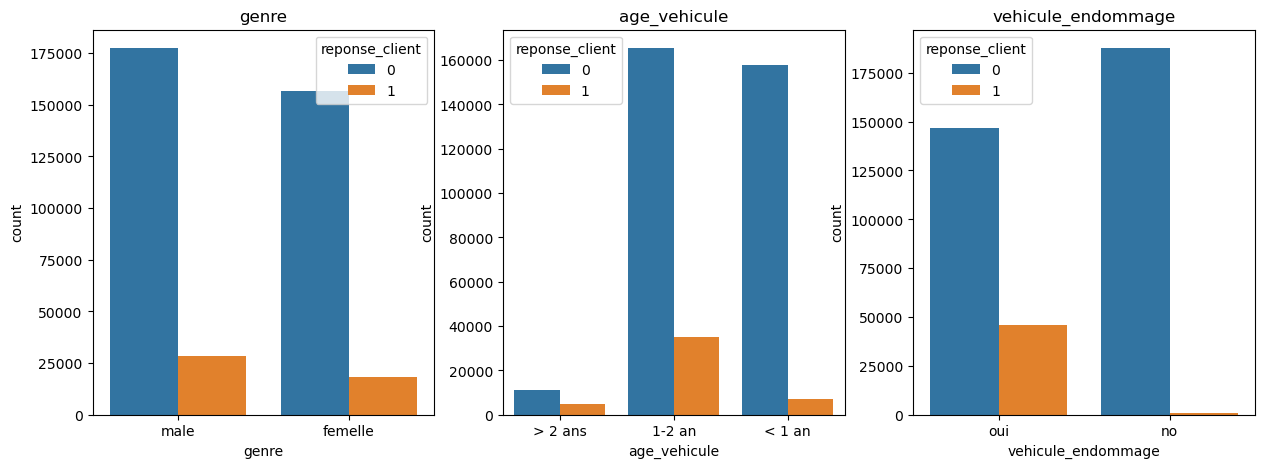

In [46]:
fg , axes = plt.subplots(1, 3 , figsize=(15, 5))
for i, col in enumerate(categorical_columns):
    sns.countplot(x=df[col], hue=df["reponse_client"], ax=axes[i])
    axes[i].set_title(col)


#### Cette visualisation confirme que les clients ayant un véhicule endommagé sont significativement plus représentés parmi ceux ayant répondu positivement.

La variable vehicule_endommage montre une forte influence sur la réponse du client. Les clients ayant un véhicule déjà endommagé présentent une proportion significativement plus élevée de réponses positives comparé à ceux dont le véhicule n’est pas endommagé. Cette variable apparaît donc comme un facteur clé dans la décision du client.

### Visualisation des variables quantitatives

In [47]:
len(numerical_columns)

8

C:\Users\pc\AppData\Local\Temp\ipykernel_6196\56917390.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue="reponse_client", ax=axes[i], fill=True)


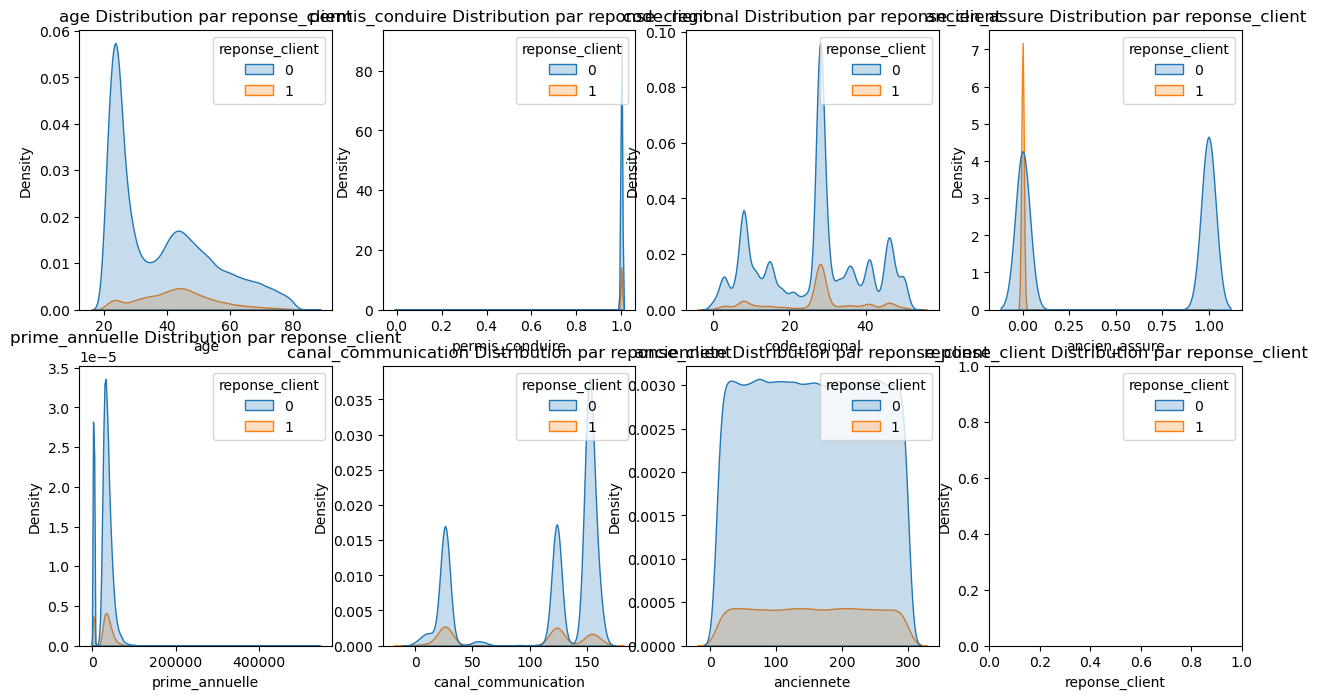

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.kdeplot(data=df, x=col, hue="reponse_client", ax=axes[i], fill=True)
    axes[i].set_title(col + " Distribution par reponse_client")

#### Le fait d’être déjà assuré influence fortement la réponse : les clients non assurés sont beaucoup plus susceptibles de répondre positivement.
#### La prime annuelle présente une forte asymétrie et des valeurs aberrantes. Son influence sur la réponse client semble limitée.

#### en generale . Parmi les variables quantitatives, le statut d’assurance (ancien_assure) apparaît comme le facteur le plus discriminant. En revanche, des variables comme permis_conduire, code_regional et anciennete montrent peu d’influence sur la réponse du client. Certaines variables comme l’âge et le canal de communication présentent une influence modérée.


Text(0.5, 1.0, 'Matrice de corrélation')

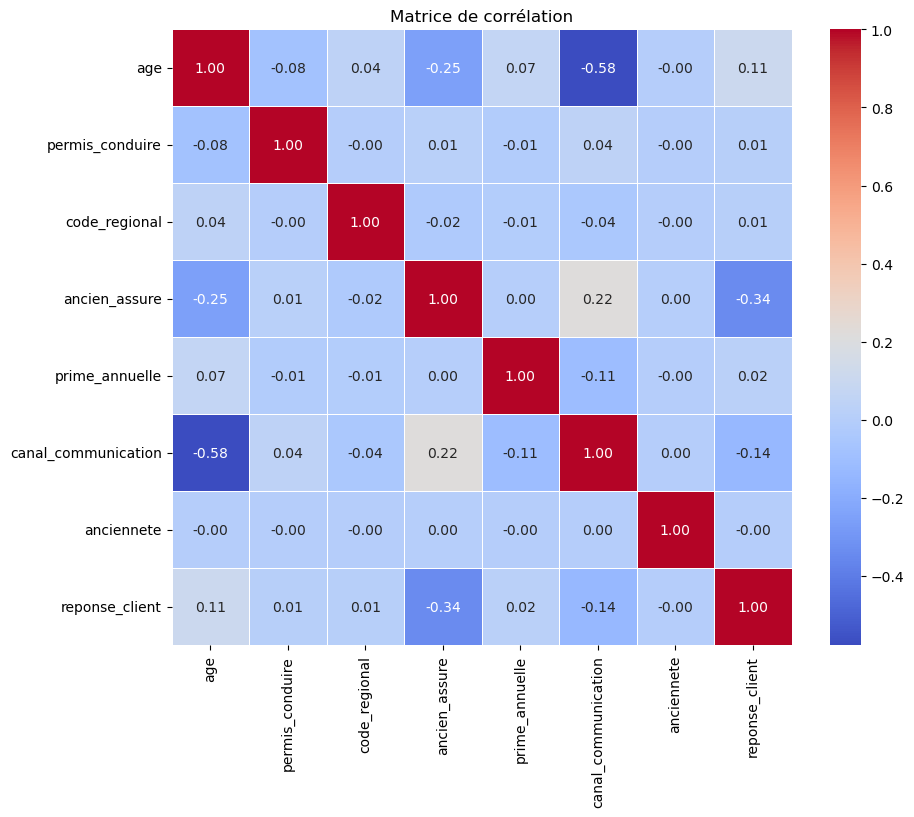

In [49]:
# identifier correlations entre les variables numériques entre eux et la variable cible
matrix_corr = df[numerical_columns].corr(method="pearson")
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")

#### La matrice de corrélation montre que la variable la plus liée à la réponse du client est le fait d’être déjà assuré, avec une corrélation négative modérée (-0.34), indiquant que les clients non assurés sont plus susceptibles de répondre positivement. </br> Les autres variables présentent des corrélations faibles avec la cible, ce qui suggère une influence limitée.Par ailleurs, une corrélation notable est observée entre l’âge et le canal de communication (-0.58), indiquant que le choix du canal dépend fortement de l’âge du client.

<Axes: xlabel='age', ylabel='prime_annuelle'>

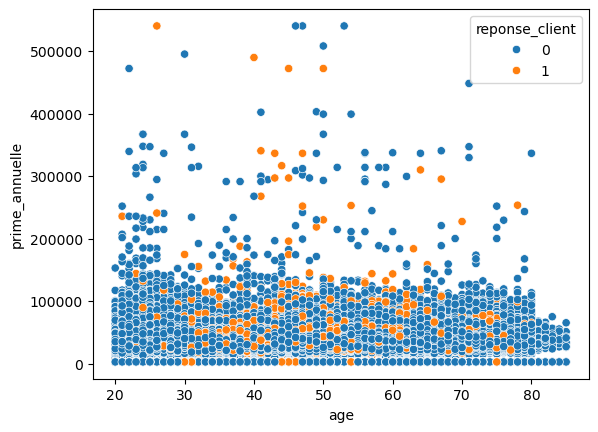

In [50]:
sns.scatterplot(data=df, x="age", y="prime_annuelle", hue="reponse_client")

<Axes: xlabel='age', ylabel='anciennete'>

c:\Users\pc\anaconda3\Lib\site-packages\IPython\core\events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\pc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


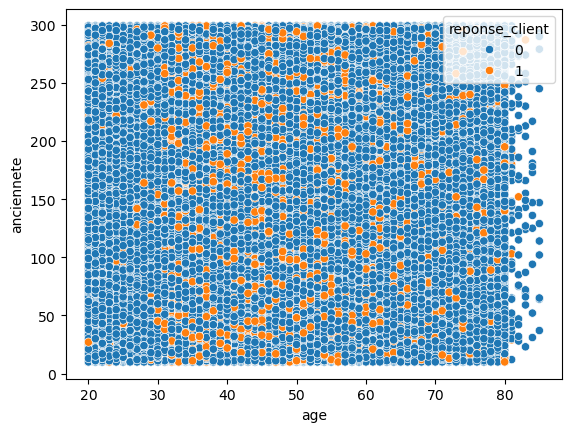

In [51]:
sns.scatterplot(data=df, x="age", y="anciennete", hue="reponse_client")

<Axes: xlabel='age', ylabel='vehicule_endommage'>

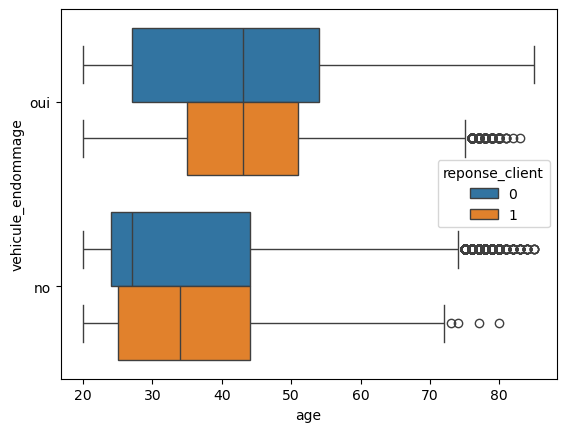

In [52]:
sns.boxplot(data=df, x="age", y="vehicule_endommage", hue="reponse_client")

L’analyse de l’âge en fonction de l’état du véhicule et de la réponse client montre que l’âge a une influence modérée lorsque le véhicule est endommagé, les clients plus âgés étant légèrement plus susceptibles de répondre positivement. En revanche, lorsque le véhicule n’est pas endommagé, cette influence devient négligeable.

<Axes: xlabel='anciennete', ylabel='vehicule_endommage'>

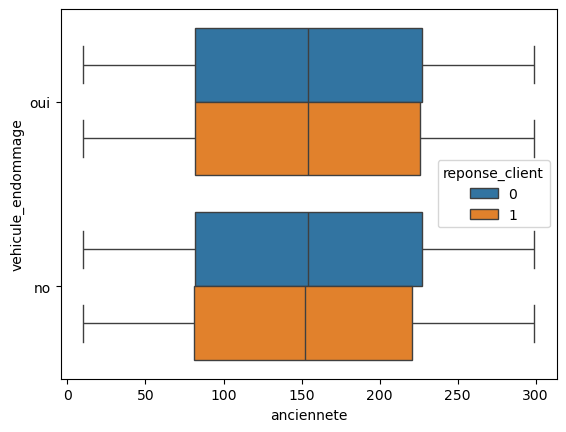

In [53]:
sns.boxplot(data=df, x="anciennete", y="vehicule_endommage", hue="reponse_client")

L’analyse de l’ancienneté en fonction de l’état du véhicule et de la réponse client montre des distributions très similaires entre les différents groupes. Cela suggère que l’ancienneté n’a pas d’impact significatif sur la décision du client.

<Axes: xlabel='age_vehicule', ylabel='count'>

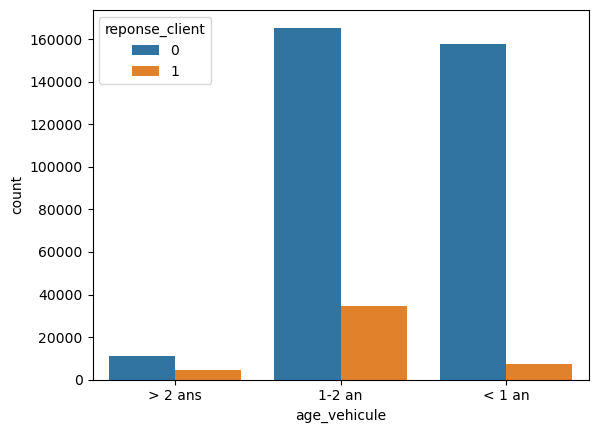

In [54]:
sns.countplot(x=df["age_vehicule"], hue=df["reponse_client"])

<Axes: xlabel='vehicule_endommage', ylabel='count'>

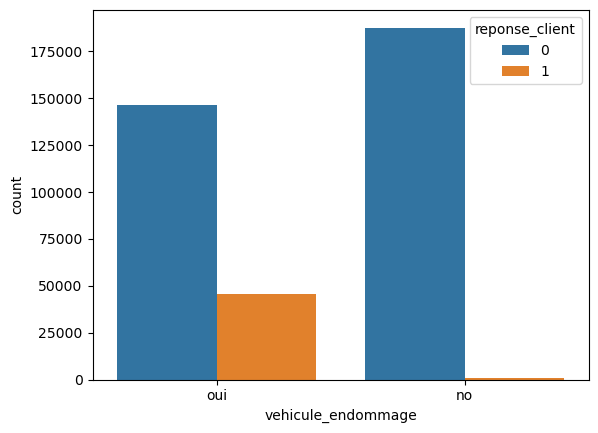

In [55]:
sns.countplot(x=df["vehicule_endommage"], hue=df["reponse_client"])

In [56]:
df.head()

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0


In [57]:
df["ancien_assure"].value_counts()

ancien_assure
0    206481
1    174628
Name: count, dtype: int64

In [58]:
df["reponse_client"].value_counts()

reponse_client
0    334399
1     46710
Name: count, dtype: int64

#### L’analyse de la variable cible révèle un fort déséquilibre entre les classes, avec une proportion largement majoritaire de clients n’ayant pas répondu positivement. Ce déséquilibre peut biaiser les performances du modèle en favorisant la classe majoritaire. Il sera donc nécessaire d’adopter des métriques adaptées et éventuellement des techniques de rééquilibrage afin d’améliorer la prédiction de la classe minoritaire.

In [59]:
df["code_regional"].unique()

array([28.,  3., 11., 41., 33.,  6., 35., 50., 15., 45.,  8., 36., 30.,
       26., 16., 47., 48., 19., 39., 23., 37.,  5., 17.,  2.,  7., 29.,
       46., 27., 25., 13., 18., 20., 49., 22., 44.,  0.,  9., 31., 12.,
       34., 21., 10., 14., 38., 24., 40., 43., 32.,  4., 51., 42.,  1.,
       52.])

In [60]:
df["canal_communication"].unique()

array([ 26., 152., 160., 124.,  14.,  13.,  30., 156., 163., 157., 122.,
        19.,  22.,  15., 154.,  16.,  52., 155.,  11., 151., 125.,  25.,
        61.,   1.,  86.,  31., 150.,  23.,  60.,  21., 121.,   3., 139.,
        12.,  29.,  55.,   7.,  47., 127., 153.,  78., 158.,  89.,  32.,
         8.,  10., 120.,  65.,   4.,  42.,  83., 136.,  24.,  18.,  56.,
        48., 106.,  54.,  93., 116.,  91.,  45.,   9., 145., 147.,  44.,
       109.,  37., 140., 107., 128., 131., 114., 118., 159., 119., 105.,
       135.,  62., 138., 129.,  88.,  92., 111., 113.,  73.,  36.,  28.,
        35.,  59.,  53., 148., 133., 108.,  64.,  39.,  94., 132.,  46.,
        81., 103.,  90.,  51.,  27., 146.,  63.,  96.,  40.,  66., 100.,
        95., 123.,  98.,  75.,  69., 130., 134.,  49.,  97.,  38.,  17.,
       110.,  80.,  71., 117.,  58.,  20.,  76., 104.,  87.,  84., 137.,
       126.,  68.,  67., 101., 115.,  57.,  82.,  79., 112.,  99.,  70.,
         2.,  34.,  33.,  74., 102., 149.,  43.,   

In [61]:
df_second.head()

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete
0,381110,male,25,1,11.0,1,< 1 an,no,35786.0,152.0,53
1,381111,male,40,1,28.0,0,1-2 an,oui,33762.0,7.0,111
2,381112,male,47,1,28.0,0,1-2 an,oui,40050.0,124.0,199
3,381113,male,24,1,27.0,1,< 1 an,oui,37356.0,152.0,187
4,381114,male,27,1,28.0,1,< 1 an,no,59097.0,152.0,297


In [62]:
df.shape

(381109, 12)

In [63]:
df_second.shape

(127037, 11)

# Feature Engineering

In [64]:
df["age"].unique()

array([44, 76, 47, 21, 29, 24, 23, 56, 32, 41, 71, 37, 25, 42, 60, 65, 49,
       34, 51, 26, 57, 79, 48, 45, 72, 30, 54, 27, 38, 22, 78, 20, 39, 62,
       58, 59, 63, 50, 67, 77, 28, 69, 52, 31, 33, 43, 36, 53, 70, 46, 55,
       40, 61, 75, 64, 35, 66, 68, 74, 73, 84, 83, 81, 80, 82, 85],
      dtype=int64)

In [65]:
df["genre"].unique()
df["genre"].value_counts()

genre
male       206089
femelle    175020
Name: count, dtype: int64

##### La variable genre a été encodée en binaire afin de la rendre exploitable par les modèles de machine learning, avec 1 pour les hommes et 0 pour les femmes. 

In [193]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
df["genre_labeled"] = lab.fit_transform(df["genre"])

In [194]:
df.head()   

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client,genre_labeled
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1,1
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0,1
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1,1
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0,1
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0,0


In [195]:
df["genre_labeled"].value_counts()    

genre_labeled
1    206089
0    175020
Name: count, dtype: int64

In [202]:
df.drop(columns=["genre_labeled"], inplace=True)

In [196]:
df["age"].describe()

count    381109.000000
mean         38.822584
std          15.511611
min          20.000000
25%          25.000000
50%          36.000000
75%          49.000000
max          85.000000
Name: age, dtype: float64

##### creer tranche age de 20 a 30  -> 1
30 , 40 -> 2 
...
70 , 80 -> 6
> 80 -> 7

In [197]:
tranch ={20:1, 30:2,40:3 ,50:4 ,60:5, 70:6, 80:7}

In [198]:
df["tranche_age"] = pd.cut(
    df["age"],
    bins=[0, 30, 40, 50, 60, 70, 80 , 100],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80+"]
)

In [199]:
df.head()

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client,genre_labeled,tranche_age
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1,1,40-50
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0,1,70-80
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1,1,40-50
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0,1,20-30
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0,0,20-30


In [203]:
df.isna().sum()

id_client              0
genre                  0
age                    0
permis_conduire        0
code_regional          0
ancien_assure          0
age_vehicule           0
vehicule_endommage     0
prime_annuelle         0
canal_communication    0
anciennete             0
reponse_client         0
tranche_age            0
dtype: int64

In [204]:
df["age_vehicule"].value_counts()

age_vehicule
1-2 an     200316
< 1 an     164786
> 2 ans     16007
Name: count, dtype: int64

In [205]:
df["vehicule_endommage"].value_counts()

vehicule_endommage
oui    192413
no     188696
Name: count, dtype: int64

In [206]:
df["ancien_assure"].value_counts()

ancien_assure
0    206481
1    174628
Name: count, dtype: int64

In [207]:
df["tranche_age_age_vehicule"] = df["tranche_age"].astype(str) + "_" + df["age_vehicule"].astype(str)
df["tranche_age_vehicule_endommage"] = df["tranche_age"].astype(str) + "_" + df["vehicule_endommage"].astype(str)
df["tranche_age_ancien_assure"] = df["tranche_age"].astype(str) + "_" + df["ancien_assure"].astype(str)
df["age_vehicule_vehicule_endommage"] = df["age_vehicule"].astype(str) + "_" + df["vehicule_endommage"].astype(str)
df["age_vehicule_ancien_assure"] = df["age_vehicule"].astype(str) + "_" + df["ancien_assure"].astype(str)
df["vehicule_endommage_ancien_assure"] = df["vehicule_endommage"].astype(str) + "_" + df["ancien_assure"].astype(str)

In [208]:
df.groupby("age_vehicule_ancien_assure")["reponse_client"].value_counts(normalize=True).unstack().fillna(0).sort_values(by=1, ascending=False)

reponse_client,0,1
age_vehicule_ancien_assure,,
> 2 ans_0,0.705470,0.294530
1-2 an_0,0.742864,0.257136
< 1 an_0,0.871419,0.128581
> 2 ans_1,0.978261,0.021739
1-2 an_1,0.998546,0.001454
< 1 an_1,0.999433,0.000567


In [209]:
df.groupby("vehicule_endommage_ancien_assure")["reponse_client"].value_counts(normalize=True).unstack().fillna(0).sort_values(by=1, ascending=False)

reponse_client,0,1
vehicule_endommage_ancien_assure,,
oui_0,0.749895,0.250105
no_0,0.962068,0.037932
oui_1,0.991332,0.008668
no_1,0.999563,0.000437


In [210]:
df.head()

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client,tranche_age,tranche_age_age_vehicule,tranche_age_vehicule_endommage,tranche_age_ancien_assure,age_vehicule_vehicule_endommage,age_vehicule_ancien_assure,vehicule_endommage_ancien_assure
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1,40-50,40-50_> 2 ans,40-50_oui,40-50_0,> 2 ans_oui,> 2 ans_0,oui_0
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0,70-80,70-80_1-2 an,70-80_no,70-80_0,1-2 an_no,1-2 an_0,no_0
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1,40-50,40-50_> 2 ans,40-50_oui,40-50_0,> 2 ans_oui,> 2 ans_0,oui_0
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0,20-30,20-30_< 1 an,20-30_no,20-30_1,< 1 an_no,< 1 an_1,no_1
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0,20-30,20-30_< 1 an,20-30_no,20-30_1,< 1 an_no,< 1 an_1,no_1


In [211]:
df.groupby("tranche_age_age_vehicule")["reponse_client"].value_counts(normalize=True).unstack().fillna(0).sort_values(by=1, ascending=False)

reponse_client,0,1
tranche_age_age_vehicule,,
40-50_> 2 ans,0.637508,0.362492
30-40_> 2 ans,0.685619,0.314381
50-60_> 2 ans,0.693014,0.306986
60-70_> 2 ans,0.767926,0.232074
30-40_1-2 an,0.777543,0.222457
50-60_< 1 an,0.784615,0.215385
20-30_1-2 an,0.788860,0.211140
40-50_1-2 an,0.799417,0.200583
40-50_< 1 an,0.815385,0.184615


In [212]:
df.groupby("tranche_age_vehicule_endommage")["reponse_client"].value_counts(normalize=True).unstack().fillna(0).sort_values(by=1, ascending=False)

reponse_client,0,1
tranche_age_vehicule_endommage,,
30-40_oui,0.665148,0.334852
40-50_oui,0.697192,0.302808
50-60_oui,0.751248,0.248752
60-70_oui,0.825557,0.174443
20-30_oui,0.861960,0.138040
70-80_oui,0.875083,0.124917
80+_oui,0.903226,0.096774
30-40_no,0.986850,0.013150
40-50_no,0.991718,0.008282


In [213]:
df.groupby("age_vehicule_vehicule_endommage")["reponse_client"].value_counts(normalize=True).unstack().fillna(0).sort_values(by=1, ascending=False)

reponse_client,0,1
age_vehicule_vehicule_endommage,,
> 2 ans_oui,0.705978,0.294022
1-2 an_oui,0.733203,0.266797
< 1 an_oui,0.858577,0.141423
1-2 an_no,0.991733,0.008267
< 1 an_no,0.996689,0.003311
> 2 ans_no,1.000000,0.000000


In [214]:
df.groupby("tranche_age_ancien_assure")["reponse_client"].value_counts(normalize=True).unstack().fillna(0).sort_values(by=1, ascending=False)

reponse_client,0,1
tranche_age_ancien_assure,,
30-40_0,0.681560,0.318440
40-50_0,0.710439,0.289561
50-60_0,0.757945,0.242055
60-70_0,0.829869,0.170131
20-30_0,0.872624,0.127376
70-80_0,0.878038,0.121962
80+_0,0.900000,0.100000
30-40_1,0.997670,0.002330
40-50_1,0.998359,0.001641


In [215]:
from sklearn.preprocessing import OneHotEncoder
onehot_cols = [
    "genre",
    "vehicule_endommage",
    "ancien_assure",
    "tranche_age",
    "tranche_age_age_vehicule",
    "tranche_age_vehicule_endommage",
    "tranche_age_ancien_assure",
    "age_vehicule_vehicule_endommage",
    "age_vehicule_ancien_assure",
    "vehicule_endommage_ancien_assure"
]
onehot = OneHotEncoder(drop="first", sparse_output=False)
encoded = onehot.fit_transform(df[onehot_cols])
encoded_df = pd.DataFrame(
    encoded,
    columns=onehot.get_feature_names_out(onehot_cols)
)

In [216]:
encoded_df.head()

,genre_male,vehicule_endommage_oui,ancien_assure_1,tranche_age_30-40,tranche_age_40-50,tranche_age_50-60,tranche_age_60-70,tranche_age_70-80,tranche_age_80+,tranche_age_age_vehicule_20-30_< 1 an,tranche_age_age_vehicule_20-30_> 2 ans,tranche_age_age_vehicule_30-40_1-2 an,tranche_age_age_vehicule_30-40_< 1 an,tranche_age_age_vehicule_30-40_> 2 ans,tranche_age_age_vehicule_40-50_1-2 an,tranche_age_age_vehicule_40-50_< 1 an,tranche_age_age_vehicule_40-50_> 2 ans,tranche_age_age_vehicule_50-60_1-2 an,tranche_age_age_vehicule_50-60_< 1 an,tranche_age_age_vehicule_50-60_> 2 ans,tranche_age_age_vehicule_60-70_1-2 an,tranche_age_age_vehicule_60-70_< 1 an,tranche_age_age_vehicule_60-70_> 2 ans,tranche_age_age_vehicule_70-80_1-2 an,tranche_age_age_vehicule_70-80_< 1 an,tranche_age_age_vehicule_70-80_> 2 ans,tranche_age_age_vehicule_80+_1-2 an,tranche_age_age_vehicule_80+_> 2 ans,tranche_age_vehicule_endommage_20-30_oui,tranche_age_vehicule_endommage_30-40_no,tranche_age_vehicule_endommage_30-40_oui,tranche_age_vehicule_endommage_40-50_no,tranche_age_vehicule_endommage_40-50_oui,tranche_age_vehicule_endommage_50-60_no,tranche_age_vehicule_endommage_50-60_oui,tranche_age_vehicule_endommage_60-70_no,tranche_age_vehicule_endommage_60-70_oui,tranche_age_vehicule_endommage_70-80_no,tranche_age_vehicule_endommage_70-80_oui,tranche_age_vehicule_endommage_80+_no,tranche_age_vehicule_endommage_80+_oui,tranche_age_ancien_assure_20-30_1,tranche_age_ancien_assure_30-40_0,tranche_age_ancien_assure_30-40_1,tranche_age_ancien_assure_40-50_0,tranche_age_ancien_assure_40-50_1,tranche_age_ancien_assure_50-60_0,tranche_age_ancien_assure_50-60_1,tranche_age_ancien_assure_60-70_0,tranche_age_ancien_assure_60-70_1,tranche_age_ancien_assure_70-80_0,tranche_age_ancien_assure_70-80_1,tranche_age_ancien_assure_80+_0,tranche_age_ancien_assure_80+_1,age_vehicule_vehicule_endommage_1-2 an_oui,age_vehicule_vehicule_endommage_< 1 an_no,age_vehicule_vehicule_endommage_< 1 an_oui,age_vehicule_vehicule_endommage_> 2 ans_no,age_vehicule_vehicule_endommage_> 2 ans_oui,age_vehicule_ancien_assure_1-2 an_1,age_vehicule_ancien_assure_< 1 an_0,age_vehicule_ancien_assure_< 1 an_1,age_vehicule_ancien_assure_> 2 ans_0,age_vehicule_ancien_assure_> 2 ans_1,vehicule_endommage_ancien_assure_no_1,vehicule_endommage_ancien_assure_oui_0,vehicule_endommage_ancien_assure_oui_1
0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [217]:
df.columns

Index(['id_client', 'genre', 'age', 'permis_conduire', 'code_regional', 'ancien_assure', 'age_vehicule', 'vehicule_endommage',
       'prime_annuelle', 'canal_communication', 'anciennete', 'reponse_client', 'tranche_age', 'tranche_age_age_vehicule',
       'tranche_age_vehicule_endommage', 'tranche_age_ancien_assure', 'age_vehicule_vehicule_endommage', 'age_vehicule_ancien_assure',
       'vehicule_endommage_ancien_assure'],
      dtype='object')

In [218]:
df.shape

(381109, 19)

In [219]:
encoded_df.shape


(381109, 67)

In [220]:
# One-Hot variables
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 67 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   genre_male                                   381109 non-null  float64
 1   vehicule_endommage_oui                       381109 non-null  float64
 2   ancien_assure_1                              381109 non-null  float64
 3   tranche_age_30-40                            381109 non-null  float64
 4   tranche_age_40-50                            381109 non-null  float64
 5   tranche_age_50-60                            381109 non-null  float64
 6   tranche_age_60-70                            381109 non-null  float64
 7   tranche_age_70-80                            381109 non-null  float64
 8   tranche_age_80+                              381109 non-null  float64
 9   tranche_age_age_vehicule_20-30_< 1 an        381109 non-nul

In [221]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ["age_vehicule"]

ordinal = OrdinalEncoder()
df[ordinal_cols] = ordinal.fit_transform(df[ordinal_cols])

In [222]:
df.loc[:, ["age_vehicule"]]

,age_vehicule
0,2.0
1,0.0
2,2.0
3,1.0
4,1.0
...,...
381104,0.0
381105,1.0
381106,1.0
381107,2.0


In [223]:
encoded_df.shape

(381109, 67)

In [224]:
df_final = pd.concat([df, encoded_df], axis=1)

In [225]:
df_final.head()

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client,tranche_age,tranche_age_age_vehicule,tranche_age_vehicule_endommage,tranche_age_ancien_assure,age_vehicule_vehicule_endommage,age_vehicule_ancien_assure,vehicule_endommage_ancien_assure,genre_male,vehicule_endommage_oui,ancien_assure_1,tranche_age_30-40,tranche_age_40-50,tranche_age_50-60,tranche_age_60-70,tranche_age_70-80,tranche_age_80+,tranche_age_age_vehicule_20-30_< 1 an,tranche_age_age_vehicule_20-30_> 2 ans,tranche_age_age_vehicule_30-40_1-2 an,tranche_age_age_vehicule_30-40_< 1 an,tranche_age_age_vehicule_30-40_> 2 ans,tranche_age_age_vehicule_40-50_1-2 an,tranche_age_age_vehicule_40-50_< 1 an,tranche_age_age_vehicule_40-50_> 2 ans,tranche_age_age_vehicule_50-60_1-2 an,tranche_age_age_vehicule_50-60_< 1 an,tranche_age_age_vehicule_50-60_> 2 ans,tranche_age_age_vehicule_60-70_1-2 an,tranche_age_age_vehicule_60-70_< 1 an,tranche_age_age_vehicule_60-70_> 2 ans,tranche_age_age_vehicule_70-80_1-2 an,tranche_age_age_vehicule_70-80_< 1 an,tranche_age_age_vehicule_70-80_> 2 ans,tranche_age_age_vehicule_80+_1-2 an,tranche_age_age_vehicule_80+_> 2 ans,tranche_age_vehicule_endommage_20-30_oui,tranche_age_vehicule_endommage_30-40_no,tranche_age_vehicule_endommage_30-40_oui,tranche_age_vehicule_endommage_40-50_no,tranche_age_vehicule_endommage_40-50_oui,tranche_age_vehicule_endommage_50-60_no,tranche_age_vehicule_endommage_50-60_oui,tranche_age_vehicule_endommage_60-70_no,tranche_age_vehicule_endommage_60-70_oui,tranche_age_vehicule_endommage_70-80_no,tranche_age_vehicule_endommage_70-80_oui,tranche_age_vehicule_endommage_80+_no,tranche_age_vehicule_endommage_80+_oui,tranche_age_ancien_assure_20-30_1,tranche_age_ancien_assure_30-40_0,tranche_age_ancien_assure_30-40_1,tranche_age_ancien_assure_40-50_0,tranche_age_ancien_assure_40-50_1,tranche_age_ancien_assure_50-60_0,tranche_age_ancien_assure_50-60_1,tranche_age_ancien_assure_60-70_0,tranche_age_ancien_assure_60-70_1,tranche_age_ancien_assure_70-80_0,tranche_age_ancien_assure_70-80_1,tranche_age_ancien_assure_80+_0,tranche_age_ancien_assure_80+_1,age_vehicule_vehicule_endommage_1-2 an_oui,age_vehicule_vehicule_endommage_< 1 an_no,age_vehicule_vehicule_endommage_< 1 an_oui,age_vehicule_vehicule_endommage_> 2 ans_no,age_vehicule_vehicule_endommage_> 2 ans_oui,age_vehicule_ancien_assure_1-2 an_1,age_vehicule_ancien_assure_< 1 an_0,age_vehicule_ancien_assure_< 1 an_1,age_vehicule_ancien_assure_> 2 ans_0,age_vehicule_ancien_assure_> 2 ans_1,vehicule_endommage_ancien_assure_no_1,vehicule_endommage_ancien_assure_oui_0,vehicule_endommage_ancien_assure_oui_1
0,1,male,44,1,28.0,0,2.0,oui,40454.0,26.0,217,1,40-50,40-50_> 2 ans,40-50_oui,40-50_0,> 2 ans_oui,> 2 ans_0,oui_0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2,male,76,1,3.0,0,0.0,no,33536.0,26.0,183,0,70-80,70-80_1-2 an,70-80_no,70-80_0,1-2 an_no,1-2 an_0,no_0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,male,47,1,28.0,0,2.0,oui,38294.0,26.0,27,1,40-50,40-50_> 2 ans,40-50_oui,40-50_0,> 2 ans_oui,> 2 ans_0,oui_0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4,male,21,1,11.0,1,1.0,no,28619.0,152.0,203,0,20-30,20-30_< 1 an,20-30_no,20-30_1,< 1 an_no,< 1 an_1,no_1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,

In [226]:
df_final.shape

(381109, 86)

In [227]:
# Encodage des variables à forte cardinalité
mean_target = df.groupby("canal_communication")["reponse_client"].mean()
df["canal_communication_encoded"] = df["canal_communication"].map(mean_target)

In [228]:
mean_target = df.groupby("code_regional")["reponse_client"].mean()
mean_target.sort_values(ascending=False)
df["code_regional_encoded"] = df["code_regional"].map(mean_target)

In [229]:
df.head()

,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client,tranche_age,tranche_age_age_vehicule,tranche_age_vehicule_endommage,tranche_age_ancien_assure,age_vehicule_vehicule_endommage,age_vehicule_ancien_assure,vehicule_endommage_ancien_assure,canal_communication_encoded,code_regional_encoded
0,1,male,44,1,28.0,0,2.0,oui,40454.0,26.0,217,1,40-50,40-50_> 2 ans,40-50_oui,40-50_0,> 2 ans_oui,> 2 ans_0,oui_0,0.199385,0.187163
1,2,male,76,1,3.0,0,0.0,no,33536.0,26.0,183,0,70-80,70-80_1-2 an,70-80_no,70-80_0,1-2 an_no,1-2 an_0,no_0,0.199385,0.127662
2,3,male,47,1,28.0,0,2.0,oui,38294.0,26.0,27,1,40-50,40-50_> 2 ans,40-50_oui,40-50_0,> 2 ans_oui,> 2 ans_0,oui_0,0.199385,0.187163
3,4,male,21,1,11.0,1,1.0,no,28619.0,152.0,203,0,20-30,20-30_< 1 an,20-30_no,20-30_1,< 1 an_no,< 1 an_1,no_1,0.028624,0.112760
4,5,femelle,29,1,41.0,1,1.0,no,27496.0,152.0,39,0,20-30,20-30_< 1 an,20-30_no,20-30_1,< 1 an_no,< 1 an_1,no_1,0.028624,0.121776


In [230]:
df = pd.concat([df.drop(columns=onehot_cols), encoded_df], axis=1)

In [231]:
df.shape

(381109, 78)

In [232]:
df.head()

,id_client,age,permis_conduire,code_regional,age_vehicule,prime_annuelle,canal_communication,anciennete,reponse_client,canal_communication_encoded,code_regional_encoded,genre_male,vehicule_endommage_oui,ancien_assure_1,tranche_age_30-40,tranche_age_40-50,tranche_age_50-60,tranche_age_60-70,tranche_age_70-80,tranche_age_80+,tranche_age_age_vehicule_20-30_< 1 an,tranche_age_age_vehicule_20-30_> 2 ans,tranche_age_age_vehicule_30-40_1-2 an,tranche_age_age_vehicule_30-40_< 1 an,tranche_age_age_vehicule_30-40_> 2 ans,tranche_age_age_vehicule_40-50_1-2 an,tranche_age_age_vehicule_40-50_< 1 an,tranche_age_age_vehicule_40-50_> 2 ans,tranche_age_age_vehicule_50-60_1-2 an,tranche_age_age_vehicule_50-60_< 1 an,tranche_age_age_vehicule_50-60_> 2 ans,tranche_age_age_vehicule_60-70_1-2 an,tranche_age_age_vehicule_60-70_< 1 an,tranche_age_age_vehicule_60-70_> 2 ans,tranche_age_age_vehicule_70-80_1-2 an,tranche_age_age_vehicule_70-80_< 1 an,tranche_age_age_vehicule_70-80_> 2 ans,tranche_age_age_vehicule_80+_1-2 an,tranche_age_age_vehicule_80+_> 2 ans,tranche_age_vehicule_endommage_20-30_oui,tranche_age_vehicule_endommage_30-40_no,tranche_age_vehicule_endommage_30-40_oui,tranche_age_vehicule_endommage_40-50_no,tranche_age_vehicule_endommage_40-50_oui,tranche_age_vehicule_endommage_50-60_no,tranche_age_vehicule_endommage_50-60_oui,tranche_age_vehicule_endommage_60-70_no,tranche_age_vehicule_endommage_60-70_oui,tranche_age_vehicule_endommage_70-80_no,tranche_age_vehicule_endommage_70-80_oui,tranche_age_vehicule_endommage_80+_no,tranche_age_vehicule_endommage_80+_oui,tranche_age_ancien_assure_20-30_1,tranche_age_ancien_assure_30-40_0,tranche_age_ancien_assure_30-40_1,tranche_age_ancien_assure_40-50_0,tranche_age_ancien_assure_40-50_1,tranche_age_ancien_assure_50-60_0,tranche_age_ancien_assure_50-60_1,tranche_age_ancien_assure_60-70_0,tranche_age_ancien_assure_60-70_1,tranche_age_ancien_assure_70-80_0,tranche_age_ancien_assure_70-80_1,tranche_age_ancien_assure_80+_0,tranche_age_ancien_assure_80+_1,age_vehicule_vehicule_endommage_1-2 an_oui,age_vehicule_vehicule_endommage_< 1 an_no,age_vehicule_vehicule_endommage_< 1 an_oui,age_vehicule_vehicule_endommage_> 2 ans_no,age_vehicule_vehicule_endommage_> 2 ans_oui,age_vehicule_ancien_assure_1-2 an_1,age_vehicule_ancien_assure_< 1 an_0,age_vehicule_ancien_assure_< 1 an_1,age_vehicule_ancien_assure_> 2 ans_0,age_vehicule_ancien_assure_> 2 ans_1,vehicule_endommage_ancien_assure_no_1,vehicule_endommage_ancien_assure_oui_0,vehicule_endommage_ancien_assure_oui_1
0,1,44,1,28.0,2.0,40454.0,26.0,217,1,0.199385,0.187163,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2,76,1,3.0,0.0,33536.0,26.0,183,0,0.199385,0.127662,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,47,1,28.0,2.0,38294.0,26.0,27,1,0.199385,0.187163,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4,21,1,11.0,1.0,28619.0,152.0,203,0,0.028624,0.112760,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,5,29,1,41.0,1.0,27496.0,152.0,39,0,0.028624,0.121776,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [233]:
for col in df.columns:
    if df[col].dtype == "object":
        print(f"Colonne '{col}' is still object type")
    


In [234]:
df.drop(columns=["code_regional", "id_client","canal_communication"], inplace=True)

In [239]:
df.shape

(381109, 75)

In [263]:
df.head()

,permis_conduire,age_vehicule,prime_annuelle,anciennete,reponse_client,canal_communication_encoded,code_regional_encoded,genre_male,vehicule_endommage_oui,ancien_assure_1,tranche_age_30-40,tranche_age_40-50,tranche_age_50-60,tranche_age_60-70,tranche_age_70-80,tranche_age_80+,tranche_age_age_vehicule_20-30_< 1 an,tranche_age_age_vehicule_20-30_> 2 ans,tranche_age_age_vehicule_30-40_1-2 an,tranche_age_age_vehicule_30-40_< 1 an,tranche_age_age_vehicule_30-40_> 2 ans,tranche_age_age_vehicule_40-50_1-2 an,tranche_age_age_vehicule_40-50_< 1 an,tranche_age_age_vehicule_40-50_> 2 ans,tranche_age_age_vehicule_50-60_1-2 an,tranche_age_age_vehicule_50-60_< 1 an,tranche_age_age_vehicule_50-60_> 2 ans,tranche_age_age_vehicule_60-70_1-2 an,tranche_age_age_vehicule_60-70_< 1 an,tranche_age_age_vehicule_60-70_> 2 ans,tranche_age_age_vehicule_70-80_1-2 an,tranche_age_age_vehicule_70-80_< 1 an,tranche_age_age_vehicule_70-80_> 2 ans,tranche_age_age_vehicule_80+_1-2 an,tranche_age_age_vehicule_80+_> 2 ans,tranche_age_vehicule_endommage_20-30_oui,tranche_age_vehicule_endommage_30-40_no,tranche_age_vehicule_endommage_30-40_oui,tranche_age_vehicule_endommage_40-50_no,tranche_age_vehicule_endommage_40-50_oui,tranche_age_vehicule_endommage_50-60_no,tranche_age_vehicule_endommage_50-60_oui,tranche_age_vehicule_endommage_60-70_no,tranche_age_vehicule_endommage_60-70_oui,tranche_age_vehicule_endommage_70-80_no,tranche_age_vehicule_endommage_70-80_oui,tranche_age_vehicule_endommage_80+_no,tranche_age_vehicule_endommage_80+_oui,tranche_age_ancien_assure_20-30_1,tranche_age_ancien_assure_30-40_0,tranche_age_ancien_assure_30-40_1,tranche_age_ancien_assure_40-50_0,tranche_age_ancien_assure_40-50_1,tranche_age_ancien_assure_50-60_0,tranche_age_ancien_assure_50-60_1,tranche_age_ancien_assure_60-70_0,tranche_age_ancien_assure_60-70_1,tranche_age_ancien_assure_70-80_0,tranche_age_ancien_assure_70-80_1,tranche_age_ancien_assure_80+_0,tranche_age_ancien_assure_80+_1,age_vehicule_vehicule_endommage_1-2 an_oui,age_vehicule_vehicule_endommage_< 1 an_no,age_vehicule_vehicule_endommage_< 1 an_oui,age_vehicule_vehicule_endommage_> 2 ans_no,age_vehicule_vehicule_endommage_> 2 ans_oui,age_vehicule_ancien_assure_1-2 an_1,age_vehicule_ancien_assure_< 1 an_0,age_vehicule_ancien_assure_< 1 an_1,age_vehicule_ancien_assure_> 2 ans_0,age_vehicule_ancien_assure_> 2 ans_1,vehicule_endommage_ancien_assure_no_1,vehicule_endommage_ancien_assure_oui_0,vehicule_endommage_ancien_assure_oui_1,age
0,1,2.0,40454.0,217,1,0.199385,0.187163,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,44
1,1,0.0,33536.0,183,0,0.199385,0.127662,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76
2,1,2.0,38294.0,27,1,0.199385,0.187163,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,47
3,1,1.0,28619.0,203,0,0.028624,0.112760,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,21
4,1,1.0,27496.0,39,0,0.028624,0.121776,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.

In [ ]:
## split data into train and test
from sklearn.model_selection import train_test_split
X = df.drop(columns=["reponse_client"])
y = df["reponse_client"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [264]:
X_train.head()

,permis_conduire,age_vehicule,prime_annuelle,anciennete,canal_communication_encoded,code_regional_encoded,genre_male,vehicule_endommage_oui,ancien_assure_1,tranche_age_30-40,tranche_age_40-50,tranche_age_50-60,tranche_age_60-70,tranche_age_70-80,tranche_age_80+,tranche_age_age_vehicule_20-30__ 1 an,tranche_age_age_vehicule_20-30__ 2 ans,tranche_age_age_vehicule_30-40_1-2 an,tranche_age_age_vehicule_30-40__ 1 an,tranche_age_age_vehicule_30-40__ 2 ans,tranche_age_age_vehicule_40-50_1-2 an,tranche_age_age_vehicule_40-50__ 1 an,tranche_age_age_vehicule_40-50__ 2 ans,tranche_age_age_vehicule_50-60_1-2 an,tranche_age_age_vehicule_50-60__ 1 an,tranche_age_age_vehicule_50-60__ 2 ans,tranche_age_age_vehicule_60-70_1-2 an,tranche_age_age_vehicule_60-70__ 1 an,tranche_age_age_vehicule_60-70__ 2 ans,tranche_age_age_vehicule_70-80_1-2 an,tranche_age_age_vehicule_70-80__ 1 an,tranche_age_age_vehicule_70-80__ 2 ans,tranche_age_age_vehicule_80+_1-2 an,tranche_age_age_vehicule_80+__ 2 ans,tranche_age_vehicule_endommage_20-30_oui,tranche_age_vehicule_endommage_30-40_no,tranche_age_vehicule_endommage_30-40_oui,tranche_age_vehicule_endommage_40-50_no,tranche_age_vehicule_endommage_40-50_oui,tranche_age_vehicule_endommage_50-60_no,tranche_age_vehicule_endommage_50-60_oui,tranche_age_vehicule_endommage_60-70_no,tranche_age_vehicule_endommage_60-70_oui,tranche_age_vehicule_endommage_70-80_no,tranche_age_vehicule_endommage_70-80_oui,tranche_age_vehicule_endommage_80+_no,tranche_age_vehicule_endommage_80+_oui,tranche_age_ancien_assure_20-30_1,tranche_age_ancien_assure_30-40_0,tranche_age_ancien_assure_30-40_1,tranche_age_ancien_assure_40-50_0,tranche_age_ancien_assure_40-50_1,tranche_age_ancien_assure_50-60_0,tranche_age_ancien_assure_50-60_1,tranche_age_ancien_assure_60-70_0,tranche_age_ancien_assure_60-70_1,tranche_age_ancien_assure_70-80_0,tranche_age_ancien_assure_70-80_1,tranche_age_ancien_assure_80+_0,tranche_age_ancien_assure_80+_1,age_vehicule_vehicule_endommage_1-2 an_oui,age_vehicule_vehicule_endommage__ 1 an_no,age_vehicule_vehicule_endommage__ 1 an_oui,age_vehicule_vehicule_endommage__ 2 ans_no,age_vehicule_vehicule_endommage__ 2 ans_oui,age_vehicule_ancien_assure_1-2 an_1,age_vehicule_ancien_assure__ 1 an_0,age_vehicule_ancien_assure__ 1 an_1,age_vehicule_ancien_assure__ 2 ans_0,age_vehicule_ancien_assure__ 2 ans_1,vehicule_endommage_ancien_assure_no_1,vehicule_endommage_ancien_assure_oui_0,vehicule_endommage_ancien_assure_oui_1,age
332803,1.0,-0.893030,1.414693,0.869505,0.310706,-1.117589,-1.084776,0.990250,-0.919940,2.430649,-0.499424,-0.367331,-0.281466,-0.204033,-0.016797,-0.821282,-0.01403,2.785743,-0.167929,-0.056495,-0.477687,-0.029383,-0.11467,-0.344391,-0.022334,-0.111878,-0.262298,-0.014146,-0.094418,-0.191432,-0.006007,-0.067822,-0.015997,-0.005122,-0.384949,-0.244054,3.208393,-0.257581,-0.399126,-0.19965,-0.296000,-0.169092,-0.218609,-0.129032,-0.155432,-0.012548,-0.011165,-0.618542,3.085018,-0.228636,-0.412121,-0.239961,-0.301995,-0.191322,-0.222063,-0.164711,-0.157893,-0.126057,-0.011017,-0.012678,1.404263,-0.663310,-0.380183,-0.005122,-0.209731,-0.455461,-0.412442,-0.633601,-0.209501,-0.010715,-0.872737,1.043166,-0.163435,0.292308
116248,1.0,-0.893030,-0.575512,-1.497719,0.887848,-0.217335,0.921850,0.990250,-0.919940,2.430649,-0.499424,-0.367331,-0.281466,-0.204033,-0.016797,-0.821282,-0.01403,2.785743,-0.167929,-0.056495,-0.477687,-0.029383,-0.11467,-0.344391,-0.022334,-0.111878,-0.262298,-0.014146,-0.094418,-0.191432,-0.006007,-0.067822,-0.015997,-0.005122,-0.384949,-0.244054,3.208393,-0.257581,-0.399126,-0.19965,-0.296000,-0.169092,-0.218609,-0.129032,-0.155432,-0.012548,-0.011165,-0.618542,3.085018,-0.228636,-0.412121,-0.239961,-0.301995,-0.191322,-0.222063,-0.164711,-0.157893,-0.126057,-0.011017,-0.012678,1.404263,-0.663310,-0.380183,-0.005122,-0.209731,-0.455461,-0.412442,-0.633601,-0.209501,-0.010715,-0.872737,1.043166,-0.163435,0.276923
255005,1.0,0.837139,0.909079,0.140209,-1.088766,-1.077003,0.921850,-1.009846,1.0

In [248]:
# Standardisation des variables numériques
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler
# =========================
# 3. Définir les colonnes
# =========================

# Colonnes pour MinMaxScaler (valeurs normales)
minmax_cols = ["age", "permis_conduire"]

# Colonnes pour RobustScaler (avec outliers)
robust_cols = ["prime_annuelle"]

# Colonnes restantes → StandardScaler
# On enlève celles déjà utilisées
standard_cols = [
    col for col in X_train.columns
    if col not in minmax_cols + robust_cols
]

# =========================
# 4. Initialiser les scalers
# =========================
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

# =========================
# 5. Appliquer les scalers
# =========================

# MinMaxScaler
X_train[minmax_cols] = minmax_scaler.fit_transform(X_train[minmax_cols])
X_test[minmax_cols] = minmax_scaler.transform(X_test[minmax_cols])

# RobustScaler
X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

# StandardScaler
X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

In [249]:
X_train.head()

,permis_conduire,age_vehicule,prime_annuelle,anciennete,canal_communication_encoded,code_regional_encoded,genre_male,vehicule_endommage_oui,ancien_assure_1,tranche_age_30-40,tranche_age_40-50,tranche_age_50-60,tranche_age_60-70,tranche_age_70-80,tranche_age_80+,tranche_age_age_vehicule_20-30_< 1 an,tranche_age_age_vehicule_20-30_> 2 ans,tranche_age_age_vehicule_30-40_1-2 an,tranche_age_age_vehicule_30-40_< 1 an,tranche_age_age_vehicule_30-40_> 2 ans,tranche_age_age_vehicule_40-50_1-2 an,tranche_age_age_vehicule_40-50_< 1 an,tranche_age_age_vehicule_40-50_> 2 ans,tranche_age_age_vehicule_50-60_1-2 an,tranche_age_age_vehicule_50-60_< 1 an,tranche_age_age_vehicule_50-60_> 2 ans,tranche_age_age_vehicule_60-70_1-2 an,tranche_age_age_vehicule_60-70_< 1 an,tranche_age_age_vehicule_60-70_> 2 ans,tranche_age_age_vehicule_70-80_1-2 an,tranche_age_age_vehicule_70-80_< 1 an,tranche_age_age_vehicule_70-80_> 2 ans,tranche_age_age_vehicule_80+_1-2 an,tranche_age_age_vehicule_80+_> 2 ans,tranche_age_vehicule_endommage_20-30_oui,tranche_age_vehicule_endommage_30-40_no,tranche_age_vehicule_endommage_30-40_oui,tranche_age_vehicule_endommage_40-50_no,tranche_age_vehicule_endommage_40-50_oui,tranche_age_vehicule_endommage_50-60_no,tranche_age_vehicule_endommage_50-60_oui,tranche_age_vehicule_endommage_60-70_no,tranche_age_vehicule_endommage_60-70_oui,tranche_age_vehicule_endommage_70-80_no,tranche_age_vehicule_endommage_70-80_oui,tranche_age_vehicule_endommage_80+_no,tranche_age_vehicule_endommage_80+_oui,tranche_age_ancien_assure_20-30_1,tranche_age_ancien_assure_30-40_0,tranche_age_ancien_assure_30-40_1,tranche_age_ancien_assure_40-50_0,tranche_age_ancien_assure_40-50_1,tranche_age_ancien_assure_50-60_0,tranche_age_ancien_assure_50-60_1,tranche_age_ancien_assure_60-70_0,tranche_age_ancien_assure_60-70_1,tranche_age_ancien_assure_70-80_0,tranche_age_ancien_assure_70-80_1,tranche_age_ancien_assure_80+_0,tranche_age_ancien_assure_80+_1,age_vehicule_vehicule_endommage_1-2 an_oui,age_vehicule_vehicule_endommage_< 1 an_no,age_vehicule_vehicule_endommage_< 1 an_oui,age_vehicule_vehicule_endommage_> 2 ans_no,age_vehicule_vehicule_endommage_> 2 ans_oui,age_vehicule_ancien_assure_1-2 an_1,age_vehicule_ancien_assure_< 1 an_0,age_vehicule_ancien_assure_< 1 an_1,age_vehicule_ancien_assure_> 2 ans_0,age_vehicule_ancien_assure_> 2 ans_1,vehicule_endommage_ancien_assure_no_1,vehicule_endommage_ancien_assure_oui_0,vehicule_endommage_ancien_assure_oui_1,age
332803,1.0,-0.893030,1.414693,0.869505,0.310706,-1.117589,-1.084776,0.990250,-0.919940,2.430649,-0.499424,-0.367331,-0.281466,-0.204033,-0.016797,-0.821282,-0.01403,2.785743,-0.167929,-0.056495,-0.477687,-0.029383,-0.11467,-0.344391,-0.022334,-0.111878,-0.262298,-0.014146,-0.094418,-0.191432,-0.006007,-0.067822,-0.015997,-0.005122,-0.384949,-0.244054,3.208393,-0.257581,-0.399126,-0.19965,-0.296000,-0.169092,-0.218609,-0.129032,-0.155432,-0.012548,-0.011165,-0.618542,3.085018,-0.228636,-0.412121,-0.239961,-0.301995,-0.191322,-0.222063,-0.164711,-0.157893,-0.126057,-0.011017,-0.012678,1.404263,-0.663310,-0.380183,-0.005122,-0.209731,-0.455461,-0.412442,-0.633601,-0.209501,-0.010715,-0.872737,1.043166,-0.163435,0.292308
116248,1.0,-0.893030,-0.575512,-1.497719,0.887848,-0.217335,0.921850,0.990250,-0.919940,2.430649,-0.499424,-0.367331,-0.281466,-0.204033,-0.016797,-0.821282,-0.01403,2.785743,-0.167929,-0.056495,-0.477687,-0.029383,-0.11467,-0.344391,-0.022334,-0.111878,-0.262298,-0.014146,-0.094418,-0.191432,-0.006007,-0.067822,-0.015997,-0.005122,-0.384949,-0.244054,3.208393,-0.257581,-0.399126,-0.19965,-0.296000,-0.169092,-0.218609,-0.129032,-0.155432,-0.012548,-0.011165,-0.618542,3.085018,-0.228636,-0.412121,-0.239961,-0.301995,-0.191322,-0.222063,-0.164711,-0.157893,-0.126057,-0.011017,-0.012678,1.404263,-0.663310,-0.380183,-0.005122,-0.209731,-0.455461,-0.412442,-0.633601,-0.209501,-0.010715,-0.872737,1.043166,-0.163435,0.276923
255005,1.0,0.837139,0.909079,0.140209,-1.088766,-1.077003,0.921850,-1.009846,1.0

In [250]:
X_train.shape

(304887, 74)

In [251]:
X_test.shape

(76222, 74)

In [252]:
df["reponse_client"].value_counts()

reponse_client
0    334399
1     46710
Name: count, dtype: int64

In [253]:
X_train.columns = X_train.columns.str.replace('[\\[\\]<>]', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[\\[\\]<>]', '_', regex=True)

In [254]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score

# Création des matrices XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Paramètres (corrigés)
params = {
    'objective': 'binary:logistic',  # ✅ classification binaire
    'max_depth': 4,
    'eta': 0.1,  # learning rate
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'logloss',  # métrique interne
    'seed': 42
}

# Entraînement
num_rounds = 100
model = xgb.train(params, dtrain, num_rounds)

# =========================
# Prédictions
# =========================

y_pred_proba = model.predict(dtest)  # probabilités
y_pred = (y_pred_proba > 0.5).astype(int)  # seuil 0.5

# =========================
# Évaluation
# =========================

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8751410353966047
F1-score: 0.0031423483816905833
ROC-AUC: 0.8602345068354335

Confusion Matrix:
[[66690     9]
 [ 9508    15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.62      0.00      0.00      9523

    accuracy                           0.88     76222
   macro avg       0.75      0.50      0.47     76222
weighted avg       0.84      0.88      0.82     76222



Le modèle prédit presque tout en classe 0
Il ignore complètement la classe 1

In [255]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.8629791923591614


In [256]:
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

F1-score: 0.0031423483816905833
ROC-AUC: 0.8357733089811622


In [257]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[66690     9]
 [ 9508    15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.62      0.00      0.00      9523

    accuracy                           0.88     76222
   macro avg       0.75      0.50      0.47     76222
weighted avg       0.84      0.88      0.82     76222



In [258]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale_pos_weight:", scale_pos_weight)

Scale_pos_weight: 7.198752252131121


In [259]:
# Gestion du déséquilibre
# Approche 1 : pondération des classes
params = {
    'objective': 'binary:logistic',  
    'max_depth': 4,
    'eta': 0.1,  # learning rate
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'logloss',  
    'seed': 42, 
    'scale_pos_weight': scale_pos_weight  
}

# Entraînement
num_rounds = 100
model_xgb = xgb.train(params, dtrain, num_rounds)

# =========================
# Prédictions
# =========================

y_pred_proba = model_xgb.predict(dtest)  # probabilités
y_pred = (y_pred_proba > 0.5).astype(int)  # seuil 0.5

# =========================
# Évaluation
# =========================

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7061609509065624
F1-score: 0.4411228945726762
ROC-AUC: 0.8597195720256291

Confusion Matrix:
[[44986 21713]
 [  684  8839]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.67      0.80     66699
           1       0.29      0.93      0.44      9523

    accuracy                           0.71     76222
   macro avg       0.64      0.80      0.62     76222
weighted avg       0.90      0.71      0.76     76222



Le premier modèle présente une accuracy élevée, mais échoue à détecter la classe minoritaire, comme en témoigne un F1-score quasi nul.
En revanche, après prise en compte du déséquilibre des classes, le second modèle améliore significativement le rappel et le F1-score, au prix d’une baisse de l’accuracy.
Ce compromis est acceptable dans notre contexte, où la détection des clients susceptibles de répondre est prioritaire.

mais on a toujour probleme dans la precession on predecte tros des positives alorque que c est moins en vrai 

In [260]:
# poir ameliorer la precession je vais chnager le seuil de decision de 0.5 a 0.7
y_pred = (y_pred_proba > 0.7).astype(int)  # seuil 0.7
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7915562436042087
F1-score: 0.46855766657746856
ROC-AUC: 0.8597195720256291

Confusion Matrix:
[[53330 13369]
 [ 2519  7004]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87     66699
           1       0.34      0.74      0.47      9523

    accuracy                           0.79     76222
   macro avg       0.65      0.77      0.67     76222
weighted avg       0.88      0.79      0.82     76222



In [156]:
# Opptimisser les hyperparametres avec GridSearchCV 
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Modèle
xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

# Grille des paramètres
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# GridSearch
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',  
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Entraînement
grid.fit(X_train, y_train)

# Résultats
print("Best parameters:", grid.best_params_)
print("Best F1-score:", grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best F1-score: 0.4392778228902026


In [162]:
import  numpy as np
best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1,0.9, 0.05)
best_f1 = 0
best_thresh = 0

for t in thresholds:
    y_pred = (y_proba > t).astype(int)
    score = f1_score(y_test, y_pred)
    
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

Best threshold: 0.6500000000000001
Best F1: 0.46642689601250975


In [170]:
# # Opptimisser les hyperparametres avec GridSearchCV 
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBClassifier

# # Modèle
# xgb_model = XGBClassifier(
#     objective='binary:logistic',
#     random_state=42,
#     scale_pos_weight=scale_pos_weight
# )

# # Grille des paramètres
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1],
#     'colsample_bytree': [0.7, 0.8, 1],
#     'gamma': [0, 1, 5],              
#     'min_child_weight': [1, 5, 10]   
# }

# # GridSearch
# grid = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     scoring='f1',  
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# # Entraînement avec aerly stopping
# grid.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=False
# )

# # Résultats
# print("Best parameters:", grid.best_params_)
# print("Best F1-score:", grid.best_score_)

In [164]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 5, 10]
}

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=20,  # 🔥 seulement 20 essais au lieu de 6000+
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best F1:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.7}
Best F1: 0.44019393847204324


In [166]:
best_model = random_search.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1,0.9, 0.05)
best_f1 = 0
best_thresh = 0

for t in thresholds:
    y_pred = (y_proba > t).astype(int)
    score = f1_score(y_test, y_pred)
    
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

Best threshold: 0.6500000000000001
Best F1: 0.46636375110437966


vehicule_endommage_ancien_assure_oui_0    0.474620
ancien_assure_1                           0.244668
vehicule_endommage_oui                    0.081118
vehicule_endommage_ancien_assure_no_1     0.060389
age_vehicule_ancien_assure_1-2 an_1       0.023369
tranche_age_70-80                         0.009967
tranche_age_age_vehicule_20-30__ 1 an     0.008023
age_vehicule_ancien_assure__ 1 an_1       0.005360
tranche_age_ancien_assure_20-30_1         0.004458
canal_communication_encoded               0.004303
dtype: float32


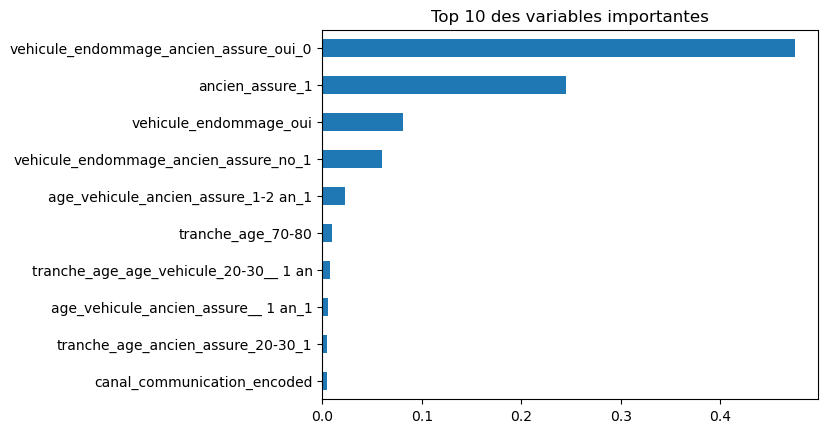

In [167]:
# importance des variables
importance = best_model.feature_importances_

# créer un dataframe
feat_imp = pd.Series(importance, index=X_train.columns)

# trier
feat_imp = feat_imp.sort_values(ascending=False)

# afficher top 10
print(feat_imp.head(10))

# visualisation
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 des variables importantes")
plt.gca().invert_yaxis()
plt.show()

L’analyse de l’importance des variables met en évidence que les caractéristiques liées à l’état du véhicule et au statut d’ancien assuré jouent un rôle majeur dans la prédiction de la réponse des clients.

En particulier, la variable combinée vehicule_endommage_ancien_assure apparaît comme la plus influente, indiquant que l’interaction entre un véhicule endommagé et le statut d’assurance est déterminante dans le comportement des clients. Cela suggère que certains profils spécifiques de clients, notamment ceux ayant un véhicule endommagé et n’étant pas anciens assurés, sont plus susceptibles de répondre.

De plus, la variable ancien_assure seule possède également une importance significative, montrant que l’historique du client avec l’assurance influence fortement sa probabilité de réponse.

L’état du véhicule (vehicule_endommage) constitue également un facteur important, ce qui peut s’expliquer par un besoin accru de couverture chez les clients dont le véhicule a subi des dommages.

Les variables liées à l’âge, telles que tranche_age, ont un impact plus faible mais non négligeable, suggérant que certaines classes d’âge présentent des comportements légèrement différents.

Enfin, la variable canal_communication_encoded a une influence limitée, ce qui indique que le canal de communication joue un rôle secondaire par rapport aux caractéristiques liées au client et à son véhicule.

Globalement, ces résultats montrent que le modèle s’appuie principalement sur des facteurs liés au véhicule et à l’historique client pour prédire la réponse, ce qui est cohérent avec le contexte métier.

La technique SMOTE a été utilisée afin de générer artificiellement de nouveaux exemples de la classe minoritaire, permettant ainsi de réduire le déséquilibre des données et d’améliorer la capacité du modèle à détecter les clients susceptibles de répondre.

In [169]:
# XGBoost + SMOTE
from imblearn.over_sampling import SMOTE


# SMOTE uniquement sur TRAIN
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Vérification
print("Avant SMOTE:", y_train.value_counts())
print("Après SMOTE:", y_train_res.value_counts())

# Entraînement
model = XGBClassifier(
    objective='binary:logistic',
    random_state=42
)

model.fit(X_train_res, y_train_res)

# Prédiction (SUR TEST NORMAL)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Avant SMOTE: reponse_client
0    267700
1     37187
Name: count, dtype: int64
Après SMOTE: reponse_client
1    267700
0    267700
Name: count, dtype: int64
Accuracy: 0.8087035239169793
F1-score: 0.43310913261537265
ROC-AUC: 0.8492327236201709

Confusion Matrix:
[[56071 10628]
 [ 3953  5570]]


In [171]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88     66699
           1       0.34      0.58      0.43      9523

    accuracy                           0.81     76222
   macro avg       0.64      0.71      0.66     76222
weighted avg       0.86      0.81      0.83     76222



In [172]:
# =========================
# Modèle avec meilleurs paramètres
# =========================
model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=1,
    min_child_weight=1,
    n_jobs=-1
)
# =========================
# Entraînement
# =========================
model.fit(X_train_res, y_train_res)

# =========================
# Prédictions (probabilités)
# =========================
y_proba = model.predict_proba(X_test)[:, 1]

# =========================
#  Seuil optimisé
# =========================
threshold = 0.65
y_pred = (y_proba > threshold).astype(int)

# =========================
#  Évaluation
# =========================
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

F1-score: 0.24045157979620263
ROC-AUC: 0.8498069019849955

Confusion Matrix:
[[64221  2478]
 [ 7883  1640]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     66699
           1       0.40      0.17      0.24      9523

    accuracy                           0.86     76222
   macro avg       0.64      0.57      0.58     76222
weighted avg       0.83      0.86      0.84     76222



la methode SMOT est rendre l accurancy plus faible que avant 

Le modèle final retenu est un modèle XGBoost (XGBClassifier) optimisé avec les paramètres suivants : une profondeur maximale de 4, un taux d’apprentissage de 0.1, un sous-échantillonnage de 0.8, ainsi qu’un paramètre scale_pos_weight fixé à 7 afin de prendre en compte le déséquilibre des classes.

Afin d’améliorer le compromis entre précision et rappel, un seuil de décision de 0.7 a été appliqué sur les probabilités de sortie du modèle.

Les performances obtenues montrent une accuracy de 0.79 et un F1-score de 0.47 pour la classe minoritaire, ce qui constitue une amélioration notable par rapport aux modèles précédents.

Plus précisément, le modèle atteint une précision de 0.35 et un rappel de 0.73 pour la classe des clients répondants. Cela signifie que le modèle est capable de détecter une proportion importante de clients susceptibles de répondre, bien qu’il génère encore un certain nombre de faux positifs.

Ce compromis est jugé acceptable dans le contexte métier, où l’objectif principal est de maximiser la détection des clients intéressés, même au prix d’une précision plus faible.

Ainsi, ce modèle offre un bon équilibre entre détection et fiabilité, ce qui en fait le meilleur choix pour la suite du projet.

In [ ]:
## instaler les methodes utiliser dans le projet pour reualiser le projet sur d'autres dataset 
import joblib

joblib.dump(model_xgb, "pkl_files/model.pkl")
joblib.dump(onehot, "pkl_files/onehot.pkl")
joblib.dump(ordinal, "pkl_files/ordinal.pkl")
joblib.dump(minmax_scaler, "pkl_files/minmax.pkl")
joblib.dump(robust_scaler, "pkl_files/robust.pkl")
joblib.dump(standard_scaler, "pkl_files/standard.pkl")


['standard.pkl']

In [ ]:

## puisuqe on a pas reponse client dans le dataset de test on va faire des prediction sur ce dataset et on va les sauvegarder dans un fichier csv pour les utiliser dans le projet finaljoblib.dump(mean_canal, "mean_canal.pkl")
df_initial = pd.read_csv("Data/train_info.csv")
mean_canal = df_initial.groupby("canal_communication")["reponse_client"].mean()
mean_region = df_initial.groupby("code_regional")["reponse_client"].mean()
joblib.dump(mean_canal, "pkl_files/mean_canal.pkl")
joblib.dump(mean_region, "pkl_files/mean_region.pkl")

['mean_region.pkl']

In [ ]:
# sauvegarder l’ordre des colonnes
joblib.dump(X_train.columns, "pkl_files/columns_order.pkl")

['columns_order.pkl']

In [ ]:
joblib.dump(standard_cols, "pkl_files/standard_cols.pkl")
joblib.dump(minmax_cols, "pkl_files/minmax_cols.pkl")
joblib.dump(robust_cols, "pkl_files/robust_cols.pkl")

['robust_cols.pkl']